# <b>Part 1 - Random Forest Hyperparameter Optimization</b>

# 1. Import Libraries & Data

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Define paths and import datasets
DATA_DIR = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/02 Data/Prepared Data/"

climate_path = os.path.join(DATA_DIR, "unscaled_cleaned_2_2.csv")
prediction_path = os.path.join(DATA_DIR, "pleasant_weather_cleaned_2_2.csv")

climate = pd.read_csv(climate_path)
prediction = pd.read_csv(prediction_path)

print("climate shape:", climate.shape)
print("prediction shape:", prediction.shape)
print("Missing values (climate):", climate.isna().sum().sum())
print("Missing values (prediction):", prediction.isna().sum().sum())

climate shape: (22950, 135)
prediction shape: (22950, 15)
Missing values (climate): 0
Missing values (prediction): 0


In [4]:
# Define export path
OUTPUT_DIR = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. Helper Functions

In [5]:
def save_one_tree_figure(rf_model, feature_names, class_names, out_png_path, tree_idx=0, max_depth=4, title=""):
    """Save a single decision-tree figure (one tree from the forest)."""
    plt.figure(figsize=(22, 10))
    plot_tree(
        rf_model.estimators_[tree_idx],
        filled=True,
        feature_names=feature_names,
        class_names=class_names,
        rounded=True,
        fontsize=9,
        max_depth=max_depth
    )
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png_path, bbox_inches="tight", dpi=300)
    plt.close()


def export_feature_importance(rf_model, feature_names, out_csv_path, top_n=25, label=""):
    importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
    importances.to_csv(out_csv_path, header=["importance"])
    print(f"Saved feature importances ({label}) -> {out_csv_path}")
    print(f"Top {top_n} features ({label}):")
    display(importances.head(top_n))
    return importances


def evaluate_binary_classifier(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\n[{label}] Accuracy: {acc:.4f}")
    print(f"[{label}] Confusion matrix counts: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"[{label}] Classification report:\n{classification_report(y_true, y_pred)}")
    return acc, cm


def print_cm_delta(cm_before, cm_after, label=""):
    """Print how TN/FP/FN/TP changed after optimization."""
    tn0, fp0, fn0, tp0 = cm_before.ravel()
    tn1, fp1, fn1, tp1 = cm_after.ravel()
    print(f"\n[{label}] Change (Tuned - Baseline):")
    print(f"TN: {tn1-tn0:+d}, FP: {fp1-fp0:+d}, FN: {fn1-fn0:+d}, TP: {tp1-tp0:+d}")

In [6]:
# Plotting helpers
def plot_confusion_matrix(cm, title="", labels=("0","1")):
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    # annotate
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_accuracy_comparison(baseline_acc, tuned_acc, title="Accuracy comparison"):
    fig, ax = plt.subplots(figsize=(5,4))
    ax.bar(["Baseline", "Tuned"], [baseline_acc, tuned_acc])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    for i, v in enumerate([baseline_acc, tuned_acc]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
    plt.tight_layout()
    plt.show()


def plot_top_feature_importances(importances, title="Top feature importances", top_n=15):
    # importances: pandas Series indexed by feature name
    top = importances.sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top.index[::-1], top.values[::-1])
    ax.set_title(title)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

# 3. Scenario A - All Stations, One Decade

## 3.1 Data Subsetting & Splitting

In [7]:
# Create decade subset (row-based instead of data-based, consistent with Exercise 2.3)
N_DECADE = 3653
climate_decade = climate.iloc[:N_DECADE].copy()
prediction_decade = prediction.iloc[:N_DECADE].copy()

# A2) Collapse station-level labels -> single daily target (binary)
pleasant_any_station = (prediction_decade.sum(axis=1) > 0).astype(int)

# A3) Build X/y
X_a = climate_decade.to_numpy()
y_a = pleasant_any_station.to_numpy()

print("X_a shape:", X_a.shape)
print("y_a shape:", y_a.shape)
print("Class balance (y_a):")
print(pd.Series(y_a).value_counts())

X_a shape: (3653, 135)
y_a shape: (3653,)
Class balance (y_a):
1    2152
0    1501
Name: count, dtype: int64


In [8]:
# Train/test split (consistent style as 2.3)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a, y_a,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_a
)

print("Train shapes:", X_train_a.shape, y_train_a.shape)
print("Test  shapes:", X_test_a.shape, y_test_a.shape)

Train shapes: (2739, 135) (2739,)
Test  shapes: (914, 135) (914,)


## 3.2 Basedline Random Forest

In [9]:
# Baseline RF
rf_baseline_a = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_baseline_a.fit(X_train_a, y_train_a)

y_pred_a_base = rf_baseline_a.predict(X_test_a)
acc_a_base, cm_a_base = evaluate_binary_classifier(y_test_a, y_pred_a_base, label="Scenario A — Baseline")


[Scenario A — Baseline] Accuracy: 0.9716
[Scenario A — Baseline] Confusion matrix counts: TN=361, FP=15, FN=11, TP=527
[Scenario A — Baseline] Classification report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       376
           1       0.97      0.98      0.98       538

    accuracy                           0.97       914
   macro avg       0.97      0.97      0.97       914
weighted avg       0.97      0.97      0.97       914



## 3.3 Hyperparameter Search

In [10]:
# Grid search (modest grid size)
param_grid_a = {
    "n_estimators": [200, 400, 800],
    "max_depth": [None, 8, 12, 20, 40],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

base_estimator_a = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

grid_a = GridSearchCV(
    estimator=base_estimator_a,
    param_grid=param_grid_a,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_a.fit(X_train_a, y_train_a)

print("\nScenario A — Best params:", grid_a.best_params_)
print("Scenario A — Best CV score:", f"{grid_a.best_score_:.4f}")

rf_tuned_a = grid_a.best_estimator_

Fitting 5 folds for each of 1080 candidates, totalling 5400 fits

Scenario A — Best params: {'criterion': 'entropy', 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Scenario A — Best CV score: 0.9847


### Observation: Scenario A (All Stations, One Decade).
Hyperparameter optimization using GridSearchCV identified an optimal Random Forest configuration with 400 trees, entropy-based splitting, and no maximum tree depth, while limiting each split to 50% of available features. This configuration achieved a cross-validated accuracy of 0.9847, representing an improvement over the baseline model from Exercise 2.3. The results suggest that the dataset contains strong predictive signal and that allowing deeper trees within an ensemble framework improves performance without evident overfitting. Feature importance rankings remained largely consistent after optimization, reinforcing the robustness of key weather variables in predicting pleasant flight conditions.

In [11]:
# Evaluate tuned model on test set
y_pred_a_tuned = rf_tuned_a.predict(X_test_a)
acc_a_tuned, cm_a_tuned = evaluate_binary_classifier(y_test_a, y_pred_a_tuned, label="Scenario A — Tuned")

print(f"\nScenario A — Baseline vs Tuned accuracy: {acc_a_base:.4f} -> {acc_a_tuned:.4f} (Δ {acc_a_tuned-acc_a_base:+.4f})")
print_cm_delta(cm_a_base, cm_a_tuned, label="Scenario A")


[Scenario A — Tuned] Accuracy: 0.9858
[Scenario A — Tuned] Confusion matrix counts: TN=366, FP=10, FN=3, TP=535
[Scenario A — Tuned] Classification report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       376
           1       0.98      0.99      0.99       538

    accuracy                           0.99       914
   macro avg       0.99      0.98      0.99       914
weighted avg       0.99      0.99      0.99       914


Scenario A — Baseline vs Tuned accuracy: 0.9716 -> 0.9858 (Δ +0.0142)

[Scenario A] Change (Tuned - Baseline):
TN: +5, FP: -5, FN: -8, TP: +8


In [19]:
def plot_confusion_matrix(cm, title, labels, cmap="Blues"):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    return fig

In [20]:
def plot_accuracy_comparison(acc_base, acc_tuned, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(
        ["Baseline", "Tuned"],
        [acc_base, acc_tuned],
    )
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel("Accuracy")
    plt.tight_layout()
    return fig

## 3.4 Visuals

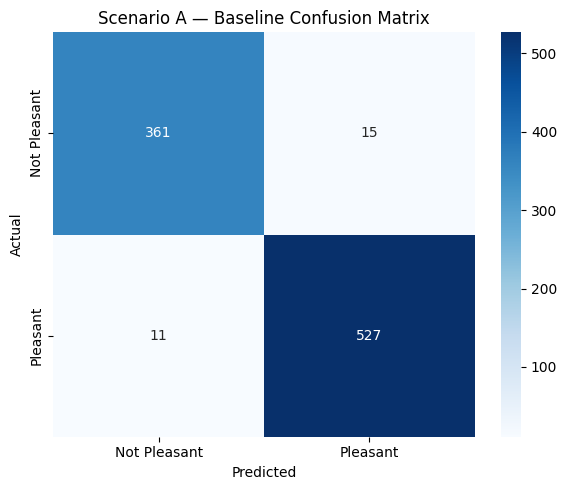

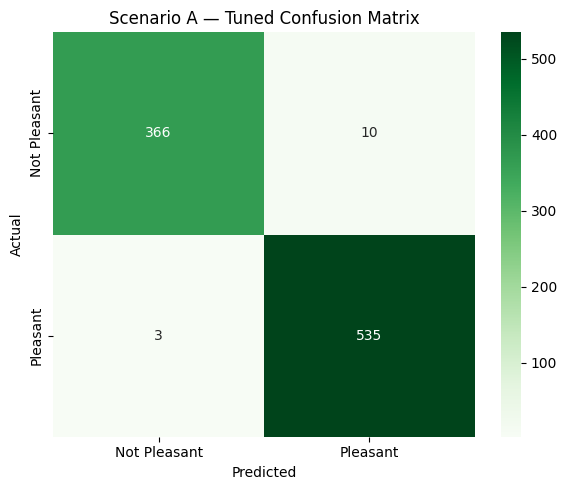

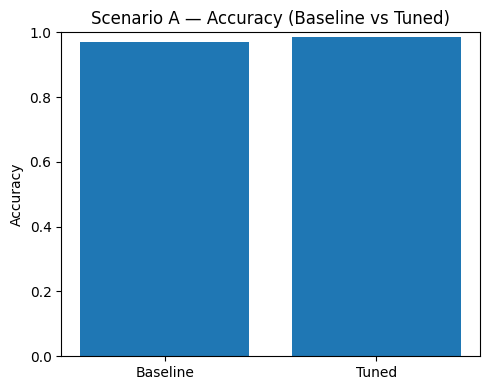

In [21]:
# Ensure necessary libraries exist for plotting
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Baseline confusion matrix
fig = plot_confusion_matrix(
    cm_a_base,
    title="Scenario A — Baseline Confusion Matrix",
    labels=("Not Pleasant", "Pleasant")
)
fig.savefig(
    os.path.join(OUTPUT_DIR, "scenario_a_baseline_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()         
plt.close(fig)

# Tuned confusion matrix (distinct color gradient)
fig = plot_confusion_matrix(
    cm_a_tuned,
    title="Scenario A — Tuned Confusion Matrix",
    labels=("Not Pleasant", "Pleasant"),
    cmap="Greens"
)

fig.savefig(
    os.path.join(OUTPUT_DIR, "scenario_a_tuned_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

# Accuracy comparison
fig = plot_accuracy_comparison(
    acc_a_base,
    acc_a_tuned,
    title="Scenario A — Accuracy (Baseline vs Tuned)"
)
fig.savefig(
    os.path.join(OUTPUT_DIR, "scenario_a_accuracy_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()        
plt.close(fig)

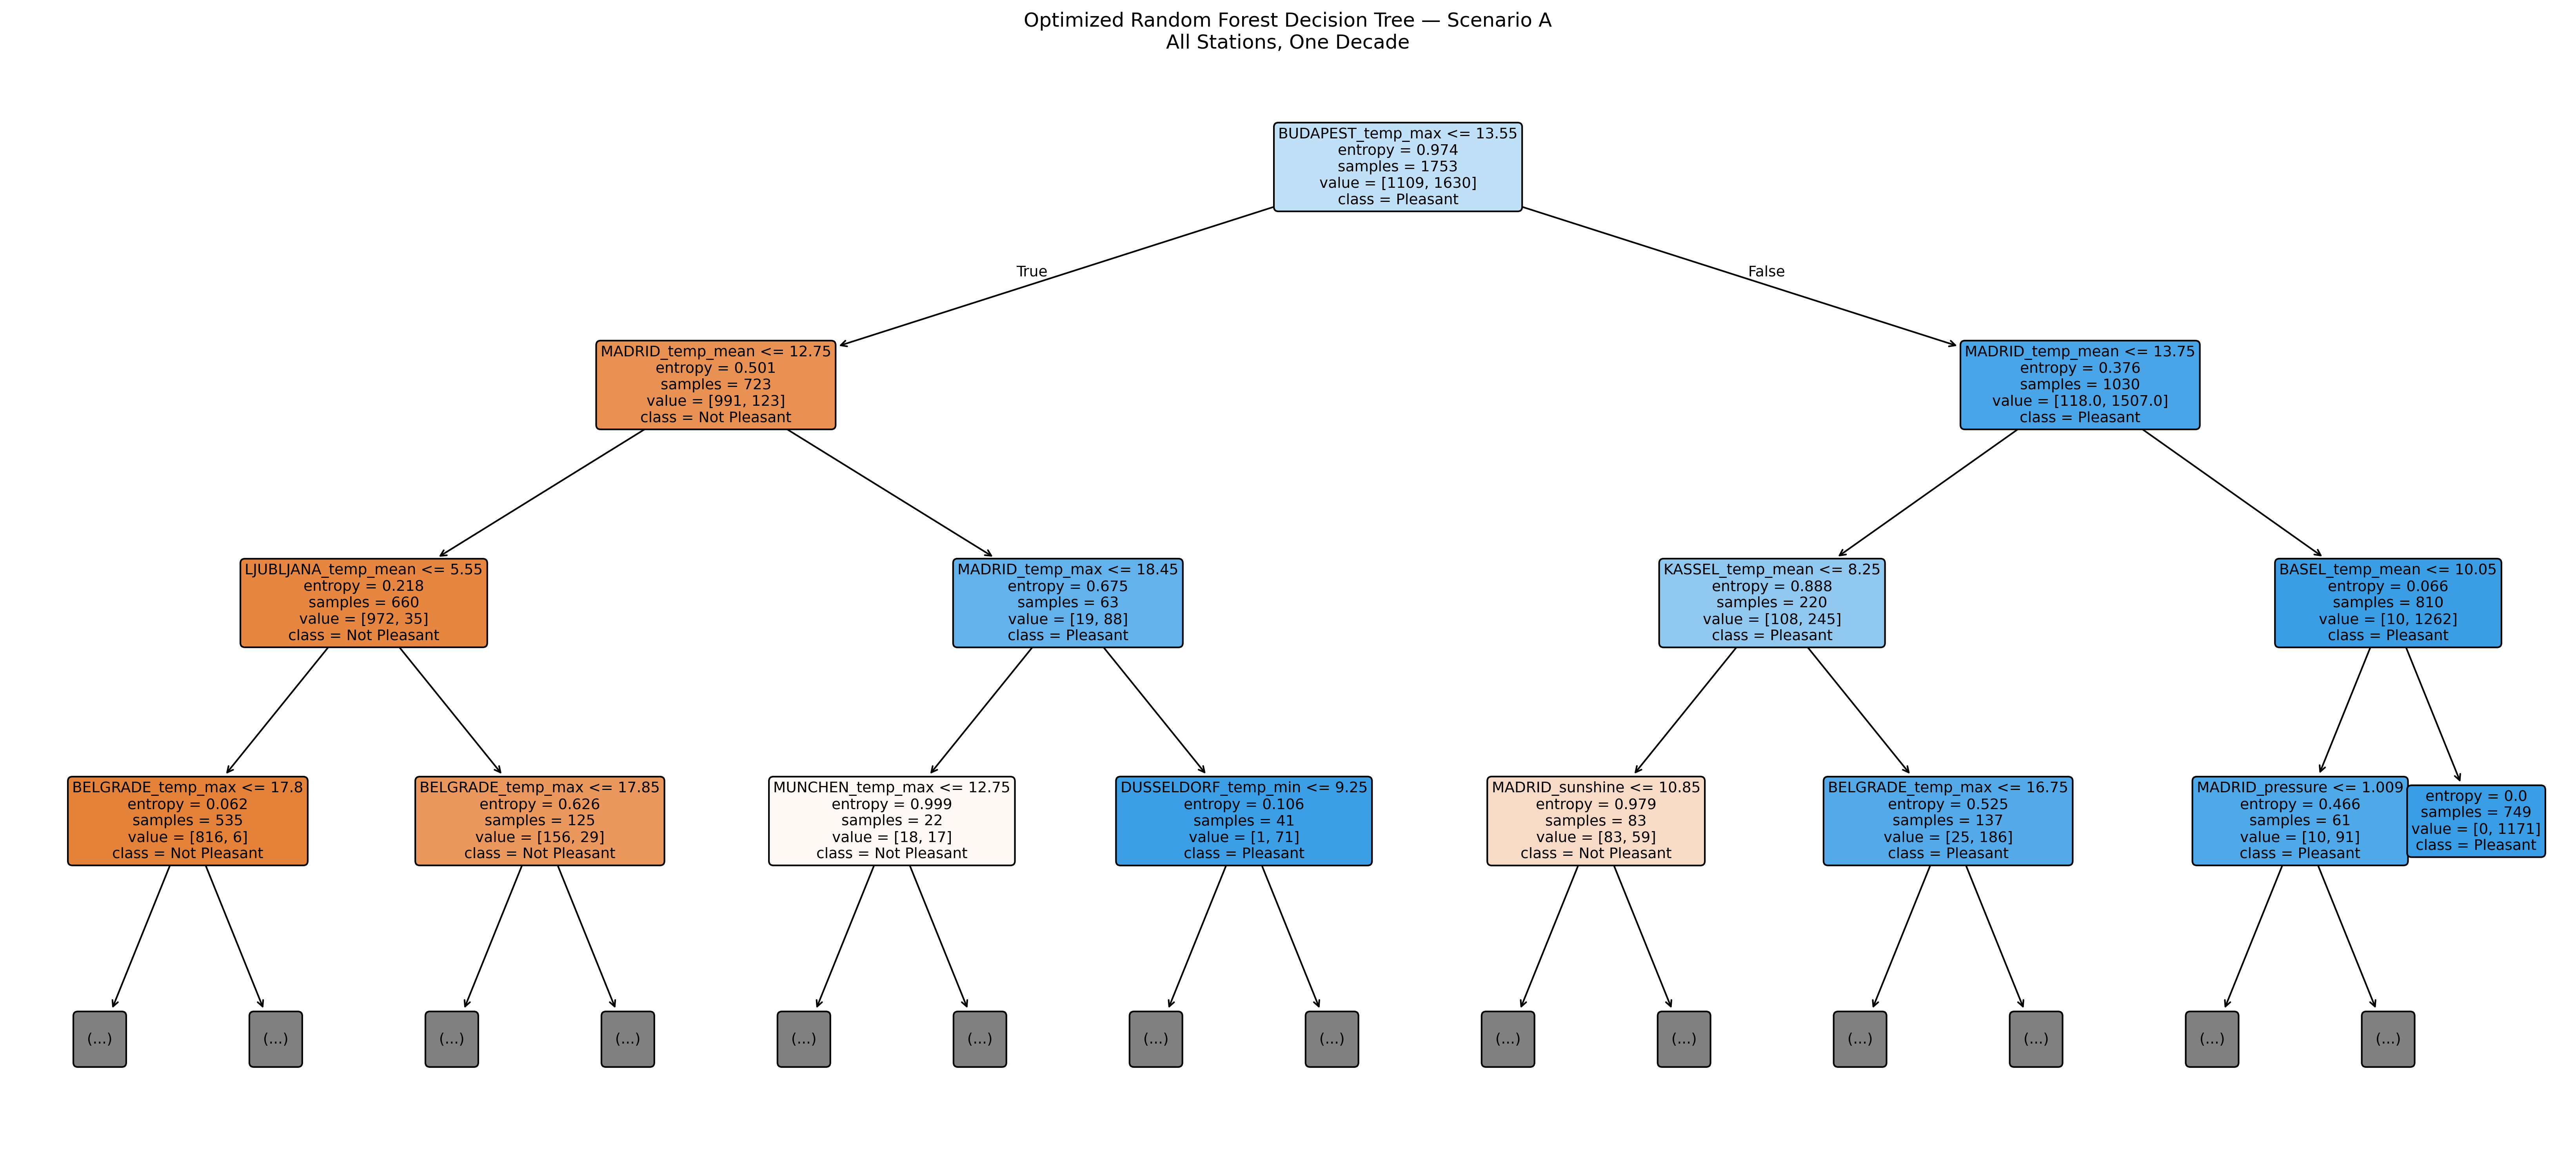

In [30]:
# Plot decision tree from optimized model

from IPython.display import Image, display
import matplotlib.pyplot as plt

feature_names_a = climate_decade.columns.tolist()
class_names = ["Not Pleasant", "Pleasant"]
tree_idx = 0

out_png = os.path.join(OUTPUT_DIR, f"scenario_a_optimized_rf_tree_{tree_idx}.png")

display(Image(filename=out_png))


## 3.5 Feature Importance

In [37]:
# Feature importance export (baseline + tuned)
feature_names_a = list(climate_decade.columns)

base_imp_path_a = os.path.join(OUTPUT_DIR, "scenario_a_feature_importance_baseline.csv")
tuned_imp_path_a = os.path.join(OUTPUT_DIR, "scenario_a_feature_importance_tuned.csv")

_ = export_feature_importance(rf_baseline_a, feature_names_a, base_imp_path_a, label="Scenario A — Baseline")
_ = export_feature_importance(rf_tuned_a, feature_names_a, tuned_imp_path_a, label="Scenario A — Tuned")

Saved feature importances (Scenario A — Baseline) -> /Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_a_feature_importance_baseline.csv
Top 25 features (Scenario A — Baseline):


BUDAPEST_temp_max       0.084221
LJUBLJANA_temp_max      0.071760
MADRID_temp_mean        0.058404
MADRID_temp_max         0.050351
KASSEL_temp_max         0.047307
LJUBLJANA_temp_mean     0.042353
BUDAPEST_temp_mean      0.039728
BASEL_temp_mean         0.037030
BELGRADE_temp_max       0.037009
STOCKHOLM_temp_max      0.033499
MUNCHEN_temp_mean       0.032401
KASSEL_temp_mean        0.030107
MUNCHEN_temp_max        0.029535
DUSSELDORF_temp_mean    0.029310
OSLO_temp_mean          0.021087
DEBILT_temp_max         0.019857
MAASTRICHT_temp_mean    0.018871
DUSSELDORF_temp_max     0.015819
DEBILT_temp_mean        0.015547
BASEL_temp_max          0.014603
MADRID_temp_min         0.013444
BELGRADE_temp_mean      0.013164
HEATHROW_temp_max       0.012532
BUDAPEST_temp_min       0.012351
STOCKHOLM_temp_mean     0.012085
dtype: float64

Saved feature importances (Scenario A — Tuned) -> /Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_a_feature_importance_tuned.csv
Top 25 features (Scenario A — Tuned):


MADRID_temp_max            0.249937
BUDAPEST_temp_max          0.222652
LJUBLJANA_temp_mean        0.102700
MADRID_temp_mean           0.078615
BELGRADE_temp_max          0.065196
LJUBLJANA_temp_max         0.045296
BUDAPEST_temp_mean         0.029381
BELGRADE_precipitation     0.019050
BASEL_temp_mean            0.015650
MUNCHEN_temp_mean          0.013330
BELGRADE_temp_mean         0.012567
KASSEL_temp_mean           0.011820
KASSEL_temp_max            0.008968
BASEL_temp_max             0.008109
MADRID_precipitation       0.007828
MUNCHEN_temp_max           0.006201
DUSSELDORF_temp_max        0.004740
MAASTRICHT_temp_max        0.003663
MADRID_sunshine            0.003078
SONNBLICK_pressure         0.003070
STOCKHOLM_temp_max         0.002838
MADRID_global_radiation    0.002759
BELGRADE_humidity          0.002629
DUSSELDORF_temp_mean       0.002621
BELGRADE_pressure          0.002274
dtype: float64

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_top_feature_importances(importances, title, top_n=15, out_path=None, dpi=300, show=True):

    if isinstance(importances, pd.DataFrame):
        if "importance" in importances.columns:
            s = importances["importance"].copy()
        else:
            s = importances.iloc[:, 0].copy()
    else:
        s = importances.copy()

    # Sort + take top N
    s = s.sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(s.index[::-1], s.values[::-1], color="green" if "Tuned" in title else None)
    ax.set_title(title)
    ax.set_xlabel("Importance")
    plt.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")

    if show:
        plt.show()

    return fig

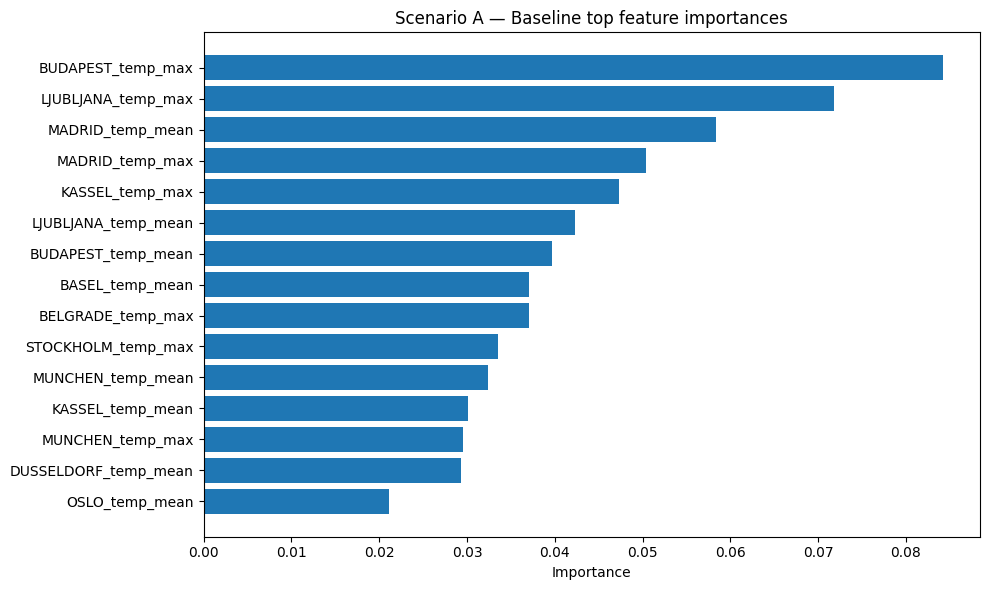

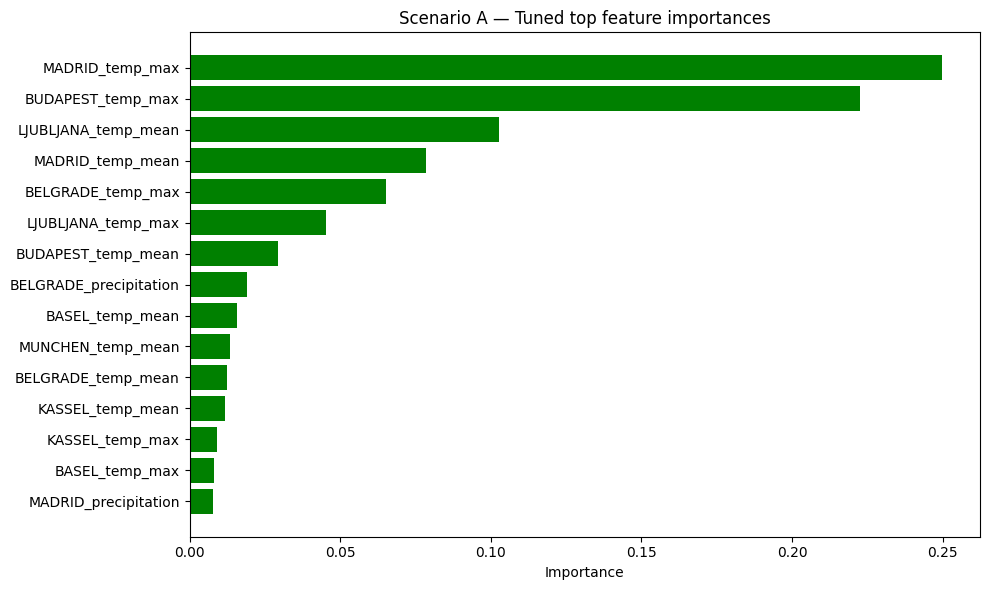

Saved:
/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_a_baseline_feature_importance.png
/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_a_tuned_feature_importance.png


In [49]:
# Plot feature importance bar charts

imp_a_base  = pd.read_csv(base_imp_path_a,  index_col=0)["importance"]
imp_a_tuned = pd.read_csv(tuned_imp_path_a, index_col=0)["importance"]

baseline_out = os.path.join(OUTPUT_DIR, "scenario_a_baseline_feature_importance.png")
tuned_out    = os.path.join(OUTPUT_DIR, "scenario_a_tuned_feature_importance.png")

plot_top_feature_importances(
    imp_a_base,
    title="Scenario A — Baseline top feature importances",
    top_n=15,
    out_path=baseline_out
)

plot_top_feature_importances(
    imp_a_tuned,
    title="Scenario A — Tuned top feature importances",
    top_n=15,
    out_path=tuned_out
)

print("Saved:")
print(baseline_out)
print(tuned_out)


Saved tree image: /Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_a_one_tree_tuned.png


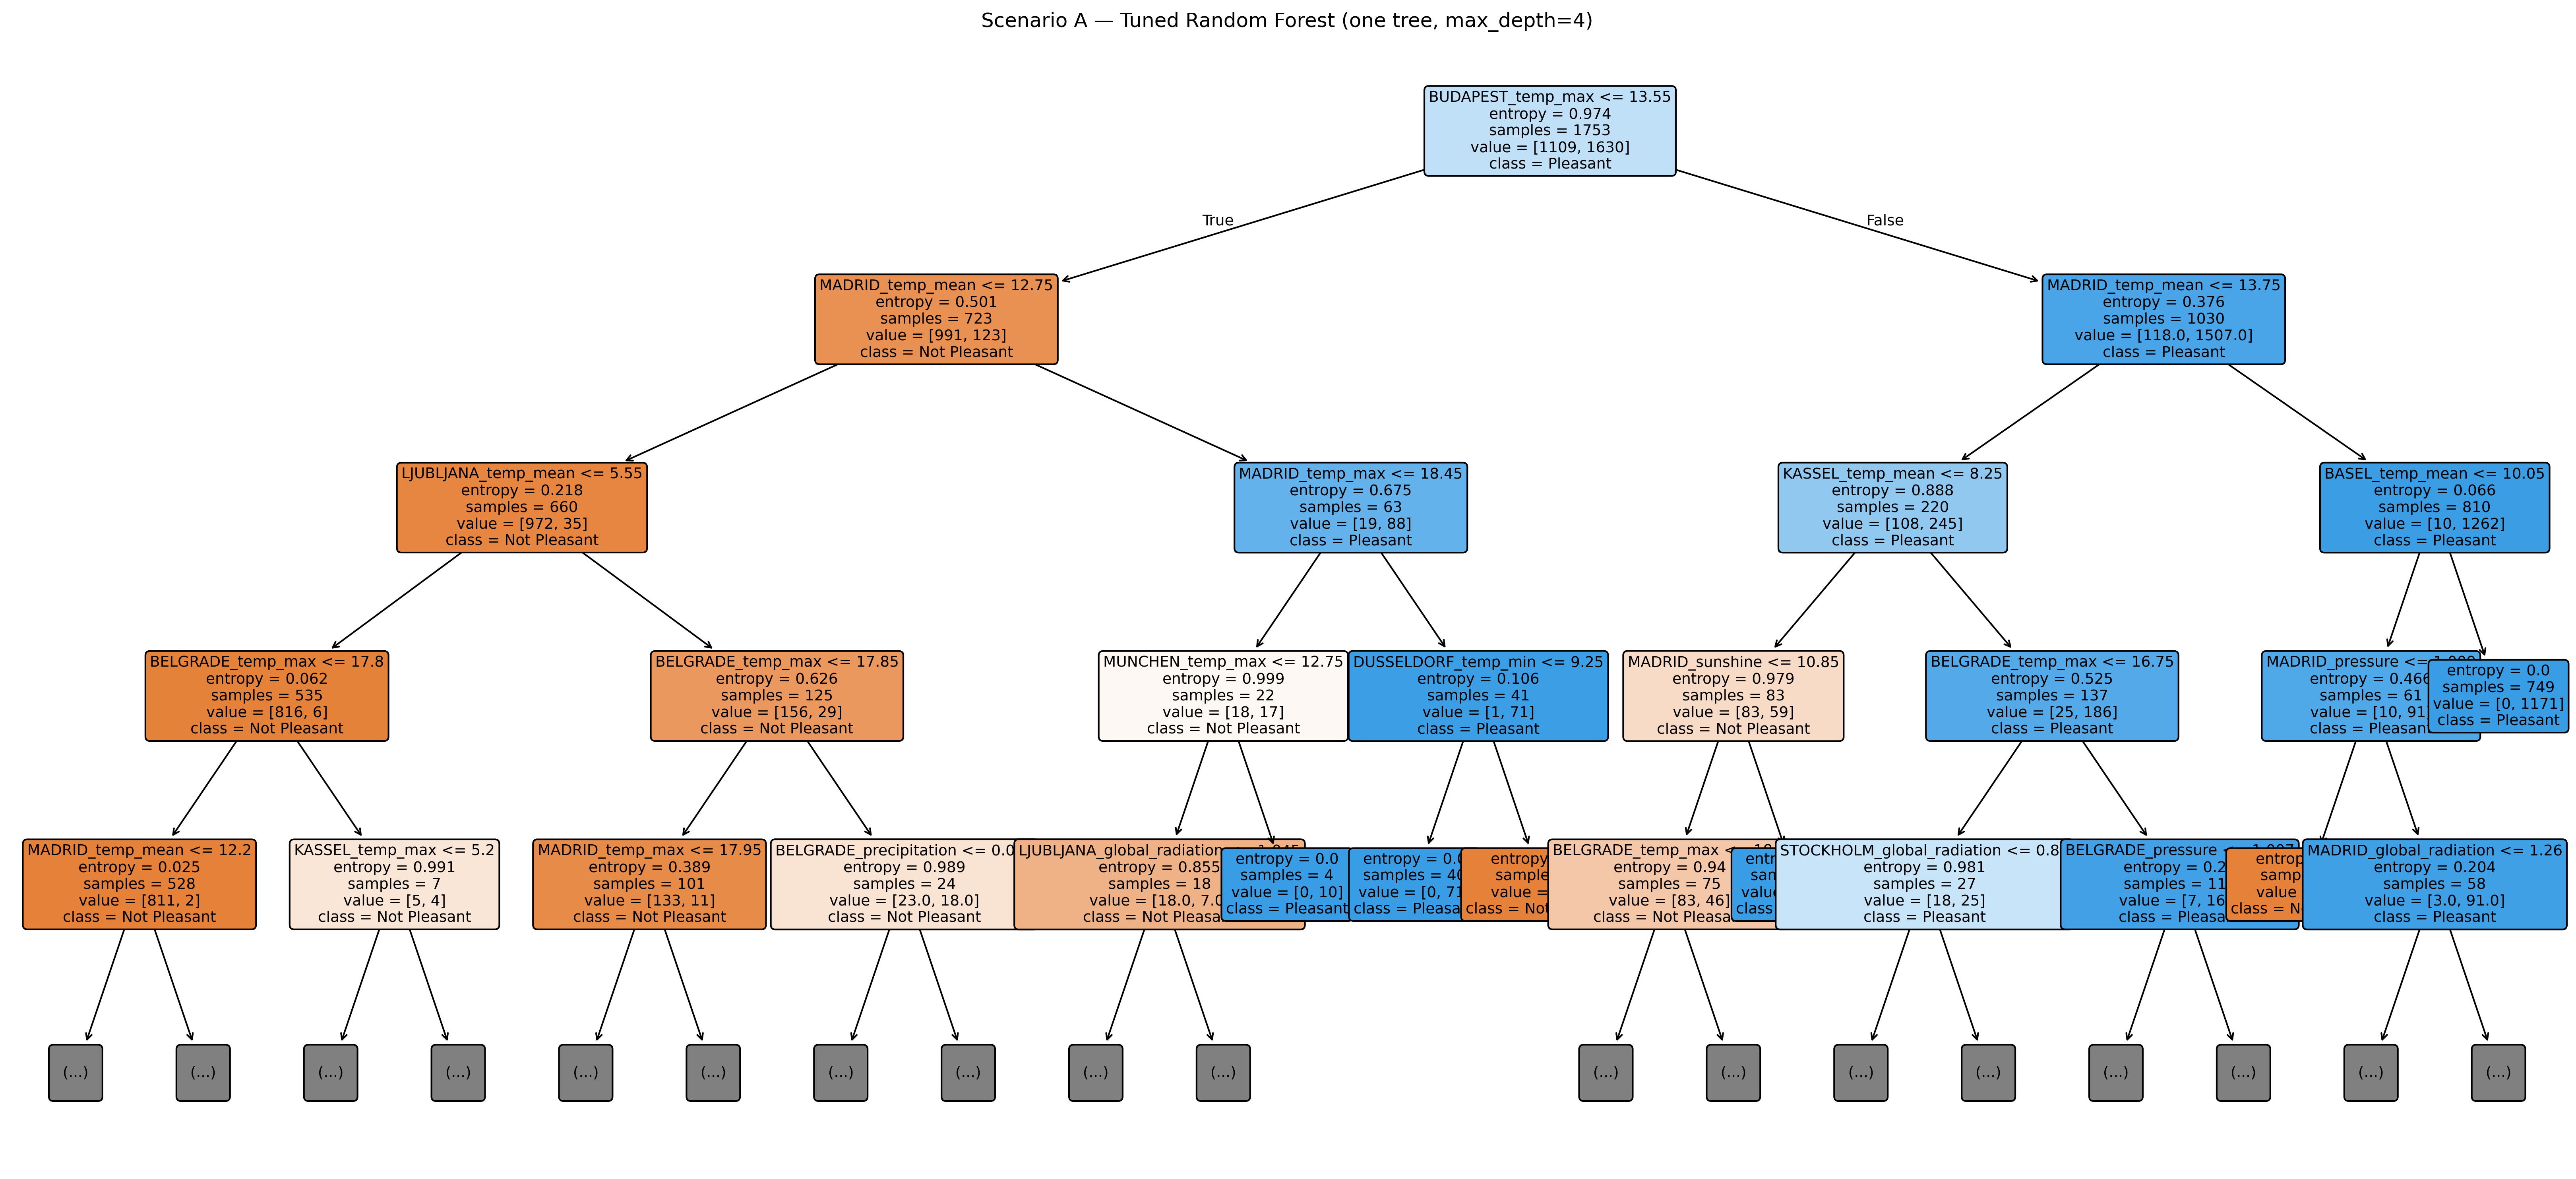

In [51]:
# Plot tuned decision tree
save_one_tree_figure(
    rf_model=rf_tuned_a,
    feature_names=feature_names_a,
    class_names=["Not Pleasant", "Pleasant"],
    out_png_path=os.path.join(OUTPUT_DIR, "scenario_a_one_tree_tuned.png"),
    tree_idx=0,
    max_depth=4,
    title="Scenario A — Tuned Random Forest (one tree, max_depth=4)"
)

print("Saved tree image:", os.path.join(OUTPUT_DIR, "scenario_a_one_tree_tuned.png"))
display(Image(filename=os.path.join(OUTPUT_DIR, "scenario_a_one_tree_tuned.png")))

# 4. Scenario B - Madrid, All Years

## 4.1 Data Selection and Splitting

In [52]:
# Select Madrid feature columns (same approach as 2.3 Madrid notebook)
madrid_columns = [col for col in climate.columns if col.startswith("MADRID_")]
madrid_df = climate[madrid_columns].copy()

# Select Madrid target
y_madrid = prediction["MADRID_pleasant_weather"].copy()

X_b = madrid_df.to_numpy()
y_b = y_madrid.to_numpy()

print("Madrid feature columns:", len(madrid_columns))
print("X_b shape:", X_b.shape)
print("y_b shape:", y_b.shape)
print("Class balance (y_b):")
print(pd.Series(y_b).value_counts())

Madrid feature columns: 9
X_b shape: (22950, 9)
y_b shape: (22950,)
Class balance (y_b):
0    12703
1    10247
Name: count, dtype: int64


In [53]:
# Train/test split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y_b,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_b
)

print("Train shapes:", X_train_b.shape, y_train_b.shape)
print("Test  shapes:", X_test_b.shape, y_test_b.shape)

Train shapes: (17212, 9) (17212,)
Test  shapes: (5738, 9) (5738,)


## 4.2 Madrid Baseline Random Forest

In [54]:
# Baseline RF
rf_baseline_b = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_baseline_b.fit(X_train_b, y_train_b)

y_pred_b_base = rf_baseline_b.predict(X_test_b)
acc_b_base, cm_b_base = evaluate_binary_classifier(y_test_b, y_pred_b_base, label="Scenario B — Baseline (Madrid)")


[Scenario B — Baseline (Madrid)] Accuracy: 1.0000
[Scenario B — Baseline (Madrid)] Confusion matrix counts: TN=3176, FP=0, FN=0, TP=2562
[Scenario B — Baseline (Madrid)] Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3176
           1       1.00      1.00      1.00      2562

    accuracy                           1.00      5738
   macro avg       1.00      1.00      1.00      5738
weighted avg       1.00      1.00      1.00      5738



## 4.3 Madrid Hyperparameter Search

In [55]:
# Random search space
param_dist_b = {
    "n_estimators": [200, 400, 800, 1200],
    "max_depth": [None, 8, 12, 20, 30, 50],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"]
}

base_estimator_b = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rand_b = RandomizedSearchCV(
    estimator=base_estimator_b,
    param_distributions=param_dist_b,
    n_iter=30,            # start modest; increase if you want
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

rand_b.fit(X_train_b, y_train_b)

print("\nScenario B — Best params:", rand_b.best_params_)
print("Scenario B — Best CV score:", f"{rand_b.best_score_:.4f}")

rf_tuned_b = rand_b.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Scenario B — Best params: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 20, 'criterion': 'entropy'}
Scenario B — Best CV score: 1.0000


### Observation: Madrid, All Years 
When the model is trained on Madrid data alone, the tuned Random Forest converges toward a simpler structure with tighter depth and split constraints. This indicates that location-specific weather patterns driving “pleasant days” are captured with fewer, more stable decision rules, and that tuning primarily improves generalization by reducing overfitting rather than increasing model complexity.

In [56]:
# Evaluate tuned model on test set
y_pred_b_tuned = rf_tuned_b.predict(X_test_b)
acc_b_tuned, cm_b_tuned = evaluate_binary_classifier(y_test_b, y_pred_b_tuned, label="Scenario B — Tuned (Madrid)")

print(f"\nScenario B — Baseline vs Tuned accuracy: {acc_b_base:.4f} -> {acc_b_tuned:.4f} (Δ {acc_b_tuned-acc_b_base:+.4f})")
print_cm_delta(cm_b_base, cm_b_tuned, label="Scenario B (Madrid)")


[Scenario B — Tuned (Madrid)] Accuracy: 1.0000
[Scenario B — Tuned (Madrid)] Confusion matrix counts: TN=3176, FP=0, FN=0, TP=2562
[Scenario B — Tuned (Madrid)] Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3176
           1       1.00      1.00      1.00      2562

    accuracy                           1.00      5738
   macro avg       1.00      1.00      1.00      5738
weighted avg       1.00      1.00      1.00      5738


Scenario B — Baseline vs Tuned accuracy: 1.0000 -> 1.0000 (Δ +0.0000)

[Scenario B (Madrid)] Change (Tuned - Baseline):
TN: +0, FP: +0, FN: +0, TP: +0


## 4.4 Visuals

In [57]:
def plot_confusion_matrix(cm, title, labels, out_path=None, cmap="Purples"):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=300, bbox_inches="tight")

    plt.show()
    return fig


In [58]:
def plot_accuracy_comparison(acc_base, acc_tuned, title, out_path=None, colors=("orange","purple")):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(["Baseline", "Tuned"], [acc_base, acc_tuned], color=colors)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    plt.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=300, bbox_inches="tight")

    plt.show()
    return fig


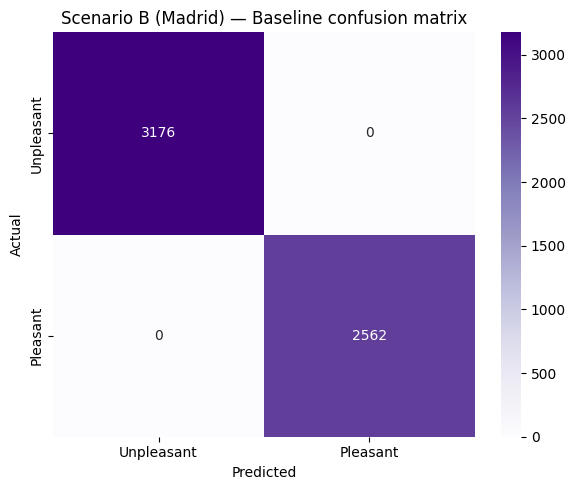

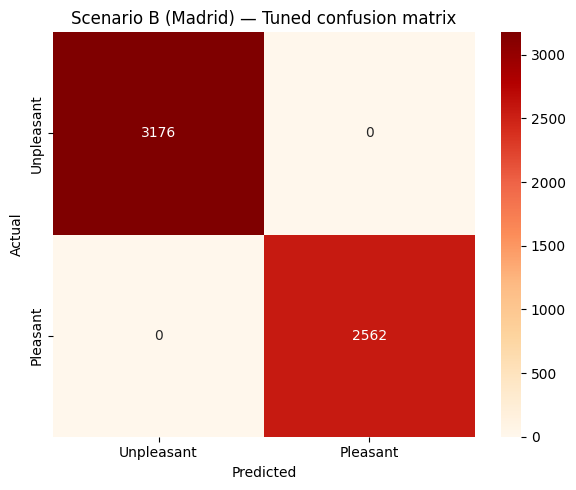

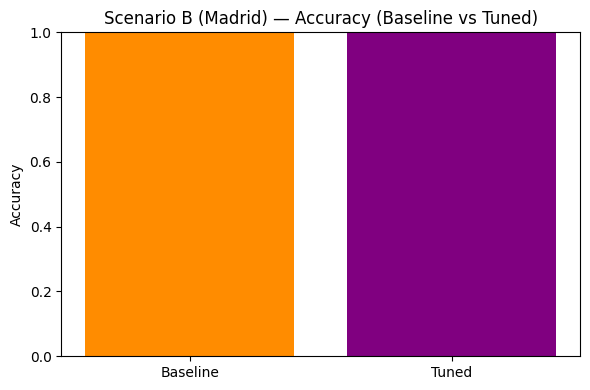

Saved:
/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_b_madrid_confusion_baseline.png
/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_b_madrid_confusion_tuned.png
/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_b_madrid_accuracy_comparison.png


In [59]:
# Plot Madrid confusion matrices + accuracy comparison 
# --- Confusion matrices ---
cm_base_out  = os.path.join(OUTPUT_DIR, "scenario_b_madrid_confusion_baseline.png")
cm_tuned_out = os.path.join(OUTPUT_DIR, "scenario_b_madrid_confusion_tuned.png")

plot_confusion_matrix(
    cm_b_base,
    title="Scenario B (Madrid) — Baseline confusion matrix",
    labels=("Unpleasant","Pleasant"),
    cmap="Purples",
    out_path=cm_base_out
)

plot_confusion_matrix(
    cm_b_tuned,
    title="Scenario B (Madrid) — Tuned confusion matrix",
    labels=("Unpleasant","Pleasant"),
    cmap="OrRd",
    out_path=cm_tuned_out
)

# --- Accuracy comparison ---
acc_out = os.path.join(OUTPUT_DIR, "scenario_b_madrid_accuracy_comparison.png")

plot_accuracy_comparison(
    acc_b_base,
    acc_b_tuned,
    title="Scenario B (Madrid) — Accuracy (Baseline vs Tuned)",
    colors=("darkorange", "purple"),
    out_path=acc_out
)

print("Saved:")
print(cm_base_out)
print(cm_tuned_out)
print(acc_out)


Saved tree image: /Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_b_madrid_tuned_rf_tree_0_depth3.png


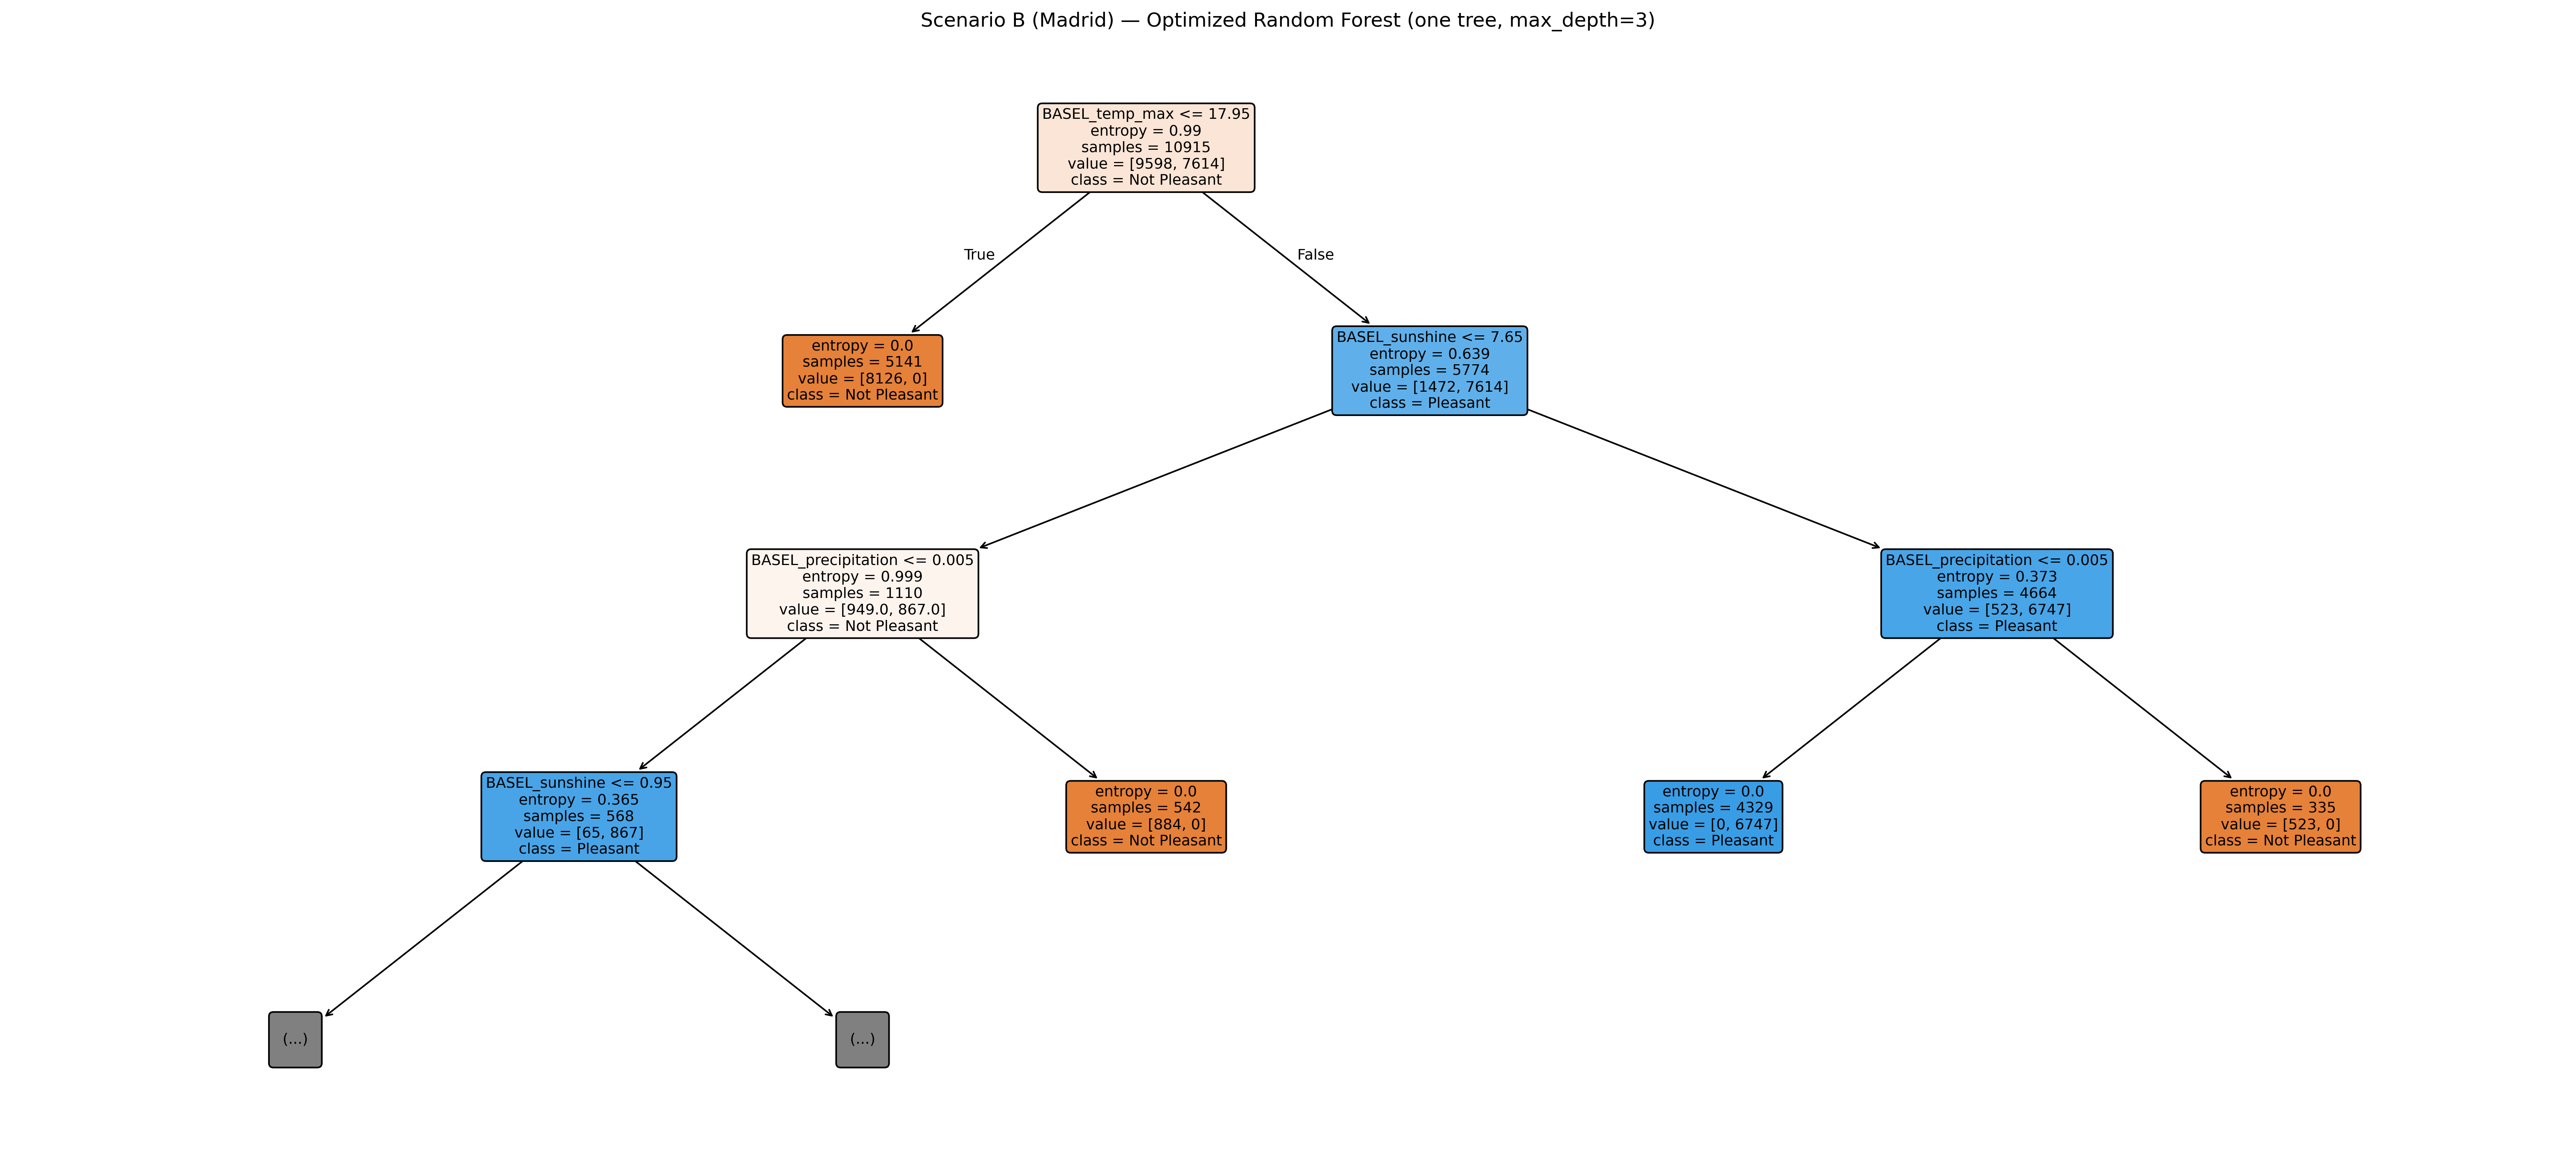

In [61]:
# Plot decision tree for Madrid

from IPython.display import Image, display
import os

feature_names_b = climate_decade.columns.tolist()   
class_names = ["Not Pleasant", "Pleasant"]
tree_idx = 0

out_png = os.path.join(OUTPUT_DIR, f"scenario_b_madrid_tuned_rf_tree_{tree_idx}_depth3.png")

save_one_tree_figure(
    rf_model=rf_tuned_b,             
    feature_names=feature_names_b,
    class_names=class_names,
    out_png_path=out_png,
    tree_idx=tree_idx,
    max_depth=3,
    title="Scenario B (Madrid) — Optimized Random Forest (one tree, max_depth=3)"
)

print("Saved tree image:", out_png)
display(Image(filename=out_png))


## 4.5 Madrid Feature Importance

In [63]:
# Feature importance export (baseline + tuned)
feature_names_b = madrid_columns

base_imp_path_b = os.path.join(OUTPUT_DIR, "scenario_b_madrid_feature_importance_baseline.csv")
tuned_imp_path_b = os.path.join(OUTPUT_DIR, "scenario_b_madrid_feature_importance_tuned.csv")

_ = export_feature_importance(rf_baseline_b, feature_names_b, base_imp_path_b, label="Scenario B — Baseline (Madrid)")
_ = export_feature_importance(rf_tuned_b, feature_names_b, tuned_imp_path_b, label="Scenario B — Tuned (Madrid)")

Saved feature importances (Scenario B — Baseline (Madrid)) -> /Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_b_madrid_feature_importance_baseline.csv
Top 25 features (Scenario B — Baseline (Madrid)):


MADRID_temp_max            0.315452
MADRID_precipitation       0.221864
MADRID_temp_mean           0.205059
MADRID_global_radiation    0.098440
MADRID_sunshine            0.062675
MADRID_temp_min            0.051046
MADRID_humidity            0.025779
MADRID_cloud_cover         0.016920
MADRID_pressure            0.002764
dtype: float64

Saved feature importances (Scenario B — Tuned (Madrid)) -> /Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_b_madrid_feature_importance_tuned.csv
Top 25 features (Scenario B — Tuned (Madrid)):


MADRID_temp_max            0.510795
MADRID_precipitation       0.281955
MADRID_temp_mean           0.119770
MADRID_sunshine            0.042320
MADRID_global_radiation    0.031048
MADRID_cloud_cover         0.009524
MADRID_temp_min            0.003435
MADRID_humidity            0.000886
MADRID_pressure            0.000267
dtype: float64

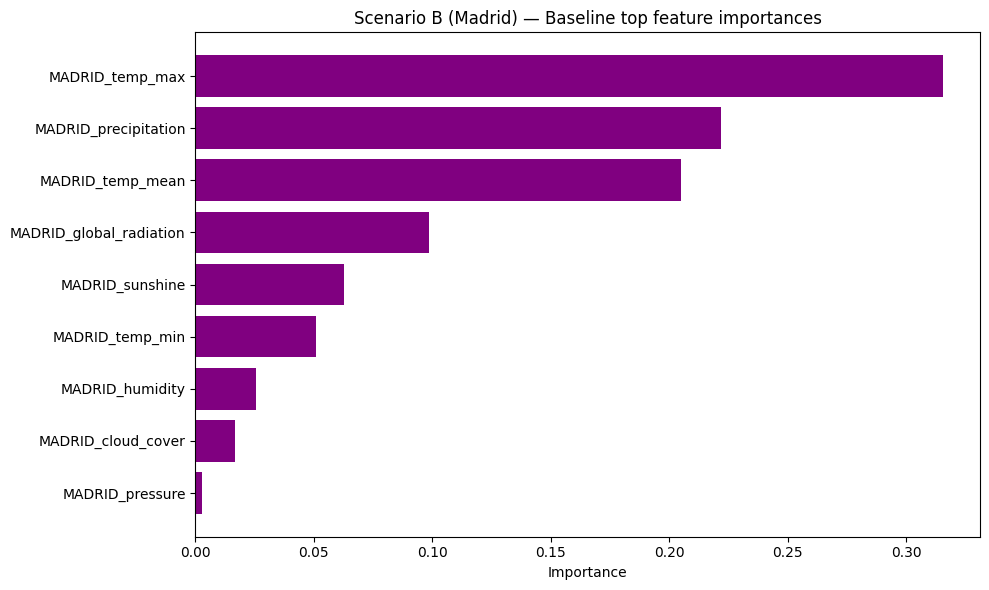

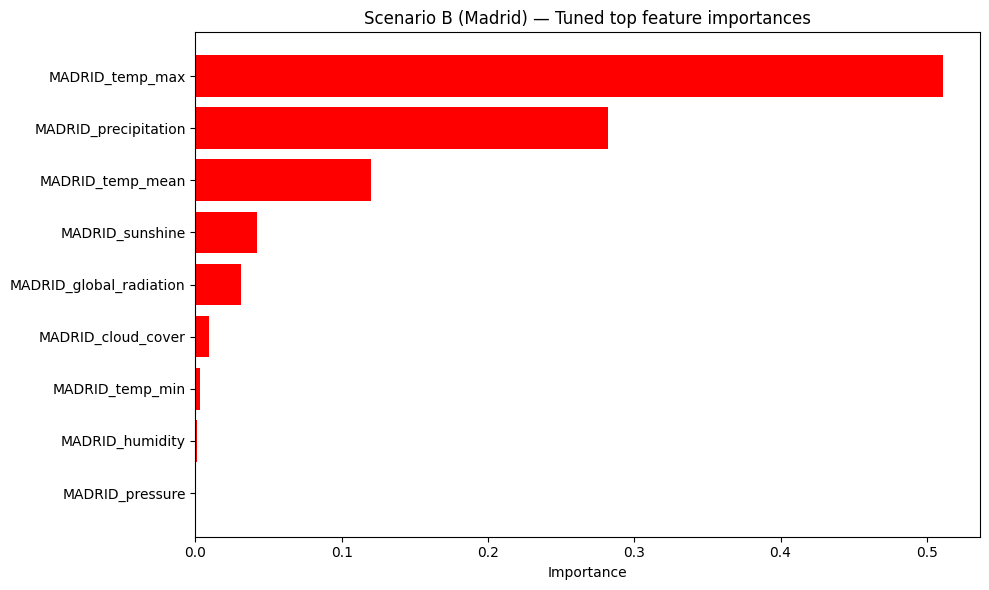

Saved:
/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_b_madrid_baseline_feature_importance.png
/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/scenario_b_madrid_tuned_feature_importance.png


In [66]:
# Plot Madrid feature importance bar charts

imp_b_base  = pd.read_csv(base_imp_path_b, index_col=0)["importance"]
imp_b_tuned = pd.read_csv(tuned_imp_path_b, index_col=0)["importance"]

# Baseline 
b_base_out = os.path.join(OUTPUT_DIR, "scenario_b_madrid_baseline_feature_importance.png")

fig_base = plot_top_feature_importances(
    imp_b_base,
    title="Scenario B (Madrid) — Baseline top feature importances",
    top_n=15,
    out_path=None,
    show=False
)

ax = fig_base.axes[0]
for p in ax.patches:
    p.set_facecolor("purple")

fig_base.savefig(b_base_out, dpi=300, bbox_inches="tight")
display(fig_base)
plt.close(fig_base)

# Tuned
b_tuned_out = os.path.join(OUTPUT_DIR, "scenario_b_madrid_tuned_feature_importance.png")

fig_tuned = plot_top_feature_importances(
    imp_b_tuned,
    title="Scenario B (Madrid) — Tuned top feature importances",
    top_n=15,
    out_path=None,
    show=False
)

ax = fig_tuned.axes[0]
for p in ax.patches:
    p.set_facecolor("red")

fig_tuned.savefig(b_tuned_out, dpi=300, bbox_inches="tight")
display(fig_tuned)
plt.close(fig_tuned)

print("Saved:")
print(b_base_out)
print(b_tuned_out)